# Validación Cruzada Estratificada para KGE

Implementación de un esquema de validación cruzada k-fold estratificada sobre grafos de conocimiento (KGs).  
La estratificación se realiza por **tipo de relación**, garantizando que cada fold mantenga la distribución relacional del dataset original.  

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from tabulate import tabulate

## 2. Carga del dataset

Se carga el dataset de tripletas `(sujeto, relación, objeto)` directamente desde GitHub en formato CSV separado por `;`.  
Se imprime una muestra, el número total de tripletas y los nombres de columnas para verificar la carga.

In [2]:
url = "https://raw.githubusercontent.com/Londad99/Stratified-Cross-Validation/main/datasets/GoT.csv"
df = pd.read_csv(url, sep=';')

print(df.head())
print(df.shape)
print(df.columns)

                        Column1      Column2  \
0                     Smithyton      SEAT_OF   
1  House Mormont of Bear Island       LED_BY   
2               Margaery Tyrell       SPOUSE   
3         Maron Nymeros Martell  ALLIED_WITH   
4  House Gargalen of Salt Shore    IN_REGION   

                             Column3  
0         House Shermer of Smithyton  
1                      Maege Mormont  
2                  Joffrey Baratheon  
3  House Nymeros Martell of Sunspear  
4                              Dorne  
(3225, 3)
Index(['Column1', 'Column2', 'Column3'], dtype='str')


## 3. Deduplicación de tripletas

Se eliminan filas duplicadas considerando las tres columnas `(sujeto, relación, objeto)`.  
Tripletas repetidas sesgarían la distribución de los folds y contaminarían la evaluación.

In [3]:
n_antes = len(df)

df = df.drop_duplicates(
    subset=[df.columns[0], df.columns[1], df.columns[2]]
).reset_index(drop=True)

n_despues = len(df)
print(f"Tripletas antes de deduplicar : {n_antes}")
print(f"Tripletas después de deduplicar: {n_despues}")
print(f"Duplicados eliminados          : {n_antes - n_despues}")

Tripletas antes de deduplicar : 3225
Tripletas después de deduplicar: 3176
Duplicados eliminados          : 49


## 4. Estrategia de etiquetado por relación

Cada tripleta recibe una **etiqueta de estrato** igual al tipo de relación (`r`).  
Esto permite que el particionamiento Round Robin distribuya uniformemente cada relación entre los k folds.

La función `label_entities_by_relation` (conservada para referencia) clasificaba entidades por heurística;  
se reemplazó por `triple_label_for_stratification`, que usa directamente el campo de relación.

In [4]:
def label_entities_by_relation(subject, relation, obj):
    """Clasifica (sujeto, objeto) según el tipo semántico de la relación. Conservada para referencia."""
    rel_map = {
        "ALLIED_WITH": ("Casa", "Casa"),
        "BRANCH_OF":   ("Casa", "Casa"),
        "FOUNDED_BY":  ("Casa", "Persona"),
        "HEIR_TO":     ("Persona", "Persona"),
        "IN_REGION":   ("Casa", "Región"),
        "LED_BY":      ("Casa", "Persona"),
        "PARENT_OF":   ("Persona", "Persona"),
        "SEAT_OF":     ("Seat", "Casa"),
        "SPOUSE":      ("Persona", "Persona"),
        "SWORN_TO":    ("Casa", "Casa")
    }
    if relation in rel_map:
        return rel_map[relation]

    def heuristic_label(entity):
        if not isinstance(entity, str):
            return "Unknown"
        e = entity.strip()
        if e.startswith("House"):
            return "Casa"
        parts = e.split()
        if len(parts) == 0:
            return "Unknown"
        if parts[0].lower() == "the":
            return "Región"
        if len(parts) <= 3:
            all_cap = all(p and p[0].isupper() for p in parts)
            if all_cap:
                return "Persona"
        return "Unknown"

    return heuristic_label(subject), heuristic_label(obj)


def triple_label_for_stratification(subject, relation, obj):
    """Etiqueta de estrato: tipo de relación de la tripleta."""
    return relation


print("Distribución de relaciones (dataset deduplicado):")
print(df.iloc[:, 1].value_counts().to_string())

Distribución de relaciones (dataset deduplicado):
Column2
ALLIED_WITH    1517
IN_REGION       437
SWORN_TO        397
SEAT_OF         243
SPOUSE          198
LED_BY          179
PARENT_OF        60
HEIR_TO          59
FOUNDED_BY       43
BRANCH_OF        42


## 5. Particionamiento estratificado k-fold (Round Robin)

Las tripletas se agrupan por relación y se distribuyen en `k` folds mediante **Round Robin** tras barajado aleatorio reproducible.  
Esto garantiza que cada fold reciba aproximadamente `1/k` de las tripletas de cada tipo de relación.

In [5]:
def create_stratified_partitions_by_triple(triples_df, k_folds=5, random_seed=42):
    np.random.seed(random_seed)
    triples = list(triples_df.itertuples(index=False, name=None))

    grouped       = defaultdict(list)
    triple_labels = {}

    for s, r, o in triples:
        lbl = triple_label_for_stratification(s, r, o)
        grouped[lbl].append((s, r, o))
        triple_labels[(s, r, o)] = lbl

    folds = [[] for _ in range(k_folds)]
    for lbl, tlist in grouped.items():
        tcopy = tlist.copy()
        np.random.shuffle(tcopy)
        for idx, triple in enumerate(tcopy):
            folds[idx % k_folds].append(triple)

    return folds, triple_labels


k_folds = 5
folds, triple_labels = create_stratified_partitions_by_triple(
    df, k_folds=k_folds, random_seed=42
)

fold_sizes = [(i + 1, len(folds[i])) for i in range(k_folds)]
print("Folds creados (cada tripleta en exactamente un fold):")
print(tabulate(fold_sizes, headers=["Fold", "Tamaño"], tablefmt="github"))

Folds creados (cada tripleta en exactamente un fold):
|   Fold |   Tamaño |
|--------|----------|
|      1 |      640 |
|      2 |      639 |
|      3 |      635 |
|      4 |      632 |
|      5 |      630 |


## 6. Verificación de los folds

Se comprueba que:
- **Ninguna tripleta aparece en más de un fold** (sin overlap exacto).
- La distribución de relaciones por fold es proporcional al dataset completo.
- Se reporta el número de entidades compartidas entre pares de folds (overlap de entidades es esperado en KGs).

In [6]:
def fold_summary_and_checks(folds, triple_labels):
    summaries          = []
    fold_entities_sets = []
    fold_objects_sets  = []

    for i, fold in enumerate(folds):
        lbl_counts    = Counter([triple_labels[t] for t in fold])
        objects       = [o for (_, _, o) in fold]
        obj_counter   = Counter(objects)
        repeated_objs = [obj for obj, cnt in obj_counter.items() if cnt > 1]
        relations     = [r for (_, r, _) in fold]
        rel_counter   = Counter(relations)
        subjects      = [s for (s, _, _) in fold]
        entities      = set(subjects) | set(objects)

        summaries.append({
            "fold":                   i + 1,
            "by_label":               dict(lbl_counts),
            "repeated_objects_count": len(repeated_objs),
            "some_repeated_objects":  repeated_objs[:8],
            "unique_relations":       len(rel_counter),
            "relation_freq_sample":   list(rel_counter.items())[:8]
        })
        fold_entities_sets.append(entities)
        fold_objects_sets.append(set(objects))

    common_entities = []
    for i in range(len(folds)):
        for j in range(i + 1, len(folds)):
            commons_ent = fold_entities_sets[i] & fold_entities_sets[j]
            common_entities.append({
                "pair":         f"{i+1}-{j+1}",
                "common_count": len(commons_ent),
                "sample":       list(commons_ent)[:5]
            })

    seen     = {}
    overlaps = []
    for i, fold in enumerate(folds):
        for t in fold:
            if t in seen:
                overlaps.append({"triple": t, "first_fold": seen[t] + 1, "second_fold": i + 1})
            else:
                seen[t] = i

    return summaries, common_entities, overlaps


summaries, common_entities, overlaps = fold_summary_and_checks(folds, triple_labels)

print(f"Overlap exacto de triples entre folds: {len(overlaps)}")
if overlaps:
    print("  Aún hay duplicados — revisar el CSV original")
else:
    print("  Sin overlap — cada tripleta está en exactamente un fold")

print()
for s in summaries:
    print(f"Fold {s['fold']}:")
    for rel, cnt in sorted(s["by_label"].items(), key=lambda x: str(x[0])):
        print(f"  {rel:<15}: {cnt}")
    print(f"  Relaciones únicas: {s['unique_relations']}")

print()
print("Entidades comunes entre pares de folds (muestra):")
for ce in common_entities[:5]:
    print(f"  Par {ce['pair']}: {ce['common_count']} entidades comunes")

Overlap exacto de triples entre folds: 0
  Sin overlap — cada tripleta está en exactamente un fold

Fold 1:
  ALLIED_WITH    : 304
  BRANCH_OF      : 9
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 88
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 80
  nan            : 1
  Relaciones únicas: 11
Fold 2:
  ALLIED_WITH    : 304
  BRANCH_OF      : 9
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 88
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 80
  Relaciones únicas: 10
Fold 3:
  ALLIED_WITH    : 303
  BRANCH_OF      : 8
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 87
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 79
  Relaciones únicas: 10
Fold 4:
  ALLIED_WITH    : 303
  BRANCH_OF      : 8
  FOUNDED_BY     : 8
  HEIR_TO        : 12
  IN_REGION      : 87
  LED_BY 

## 7. Exportar particiones a Excel

Cada fold se guarda en una hoja separada del archivo `.xlsx`, con columnas `Subject`, `Relation`, `Object` y `label`.  
El archivo se descarga automáticamente desde Colab.

In [8]:
output_name = "folds_partitions_corregido.xlsx"
with pd.ExcelWriter(output_name) as writer:
    for i, fold in enumerate(folds, start=1):
        df_fold = pd.DataFrame(fold, columns=["Subject", "Relation", "Object"])
        df_fold["label"] = df_fold.apply(
            lambda r: triple_labels[(r["Subject"], r["Relation"], r["Object"])],
            axis=1
        )
        df_fold.to_excel(writer, sheet_name=f"Fold_{i}", index=False)

print("Guardado en:", output_name)
files.download(output_name)

Guardado en: folds_partitions_corregido.xlsx


NameError: name 'files' is not defined

## 8. Funciones de evaluación con ranking filtrado

`compute_filtered_ranks` calcula el rango de cada tripleta de prueba corrupting sujeto u objeto con todas las entidades del grafo, excluyendo tripletas verdaderas conocidas (**filtered setting** estándar en KGE).  
`compute_metrics_from_ranks` agrega los rangos en MRR, Hits@1, Hits@3 y Hits@10.

In [7]:
def compute_filtered_ranks(test_triples, entities_list, score_fn, corrupt_side, filter_triples):
    ranks = []
    for s, r, o in test_triples:
        true_score       = score_fn(s, r, o)
        candidate_scores = []

        for entity in entities_list:
            if corrupt_side == "subject":
                corrupted = (entity, r, o)
            elif corrupt_side == "object":
                corrupted = (s, r, entity)
            else:
                continue

            if corrupted not in filter_triples:
                candidate_scores.append(score_fn(*corrupted))

        all_scores = sorted(candidate_scores + [true_score], reverse=True)
        ranks.append(all_scores.index(true_score) + 1)

    return ranks


def compute_metrics_from_ranks(ranks):
    if not ranks:
        return {"MRR": 0.0, "Hits@1": 0.0, "Hits@3": 0.0, "Hits@10": 0.0}

    mrr = hits1 = hits3 = hits10 = 0
    for rank in ranks:
        mrr += 1.0 / rank
        if rank <= 1:  hits1  += 1
        if rank <= 3:  hits3  += 1
        if rank <= 10: hits10 += 1

    n = len(ranks)
    return {
        "MRR":     mrr   / n,
        "Hits@1":  hits1 / n,
        "Hits@3":  hits3 / n,
        "Hits@10": hits10 / n
    }

## 9. Evaluación k-fold con modelo KGE

En cada iteración, los `k-1` folds restantes forman el conjunto de entrenamiento y el fold `i` es el conjunto de prueba.  
Al final se promedian las métricas de todos los folds.

> **Para conectar un modelo real:** reemplaza el `score_fn` placeholder por la función de puntuación del modelo entrenado.  
> Ejemplo con AmpliGraph (`TransE`):
> ```python
> from ampligraph.latent_features import TransE
> model = TransE(batches_count=100, epochs=200, k=100, eta=5,
>                optimizer='adam', optimizer_params={'lr': 1e-3},
>                loss='pairwise', regularizer='LP',
>                regularizer_params={'p': 3, 'lambda': 1e-5}, verbose=True)
> model.fit(np.array(train_triples))
> score_fn = lambda s, r, o: float(model.predict(np.array([[s, r, o]]))[0])
> ```

In [8]:
entities_list   = list({e for fold in folds for t in fold for e in (t[0], t[2])})
all_triples_set = set(t for fold in folds for t in fold)

# Placeholder — reemplazar por model.predict() del modelo entrenado
score_fn = lambda s, r, o: float(np.random.rand())

results_by_fold = defaultdict(dict)

for i, test_fold in enumerate(folds, start=1):
    train_triples  = [t for j, f in enumerate(folds, start=1) if j != i for t in f]
    filter_triples = set(train_triples) | set(test_fold) | all_triples_set

    # model.fit(np.array(train_triples))  ← descomentar al usar modelo real

    ranks_head = compute_filtered_ranks(
        test_fold, entities_list, score_fn, corrupt_side="subject", filter_triples=filter_triples
    )
    ranks_tail = compute_filtered_ranks(
        test_fold, entities_list, score_fn, corrupt_side="object", filter_triples=filter_triples
    )

    metrics = compute_metrics_from_ranks(ranks_head + ranks_tail)
    results_by_fold[f"fold_{i}"] = metrics
    print(f"Fold {i} metrics:", metrics)

keys = list(next(iter(results_by_fold.values())).keys())
avg  = {k: float(np.mean([results_by_fold[f][k] for f in results_by_fold])) for k in keys}
print("\nPromedio entre folds:", avg)


#Comparación entre modelos y documentar. Subir el collab en una carpeta. Compartir con madarme@gmail

Fold 1 metrics: {'MRR': 0.0031210504495291654, 'Hits@1': 0.0, 'Hits@3': 0.00078125, 'Hits@10': 0.0046875}
Fold 2 metrics: {'MRR': 0.002965769913649949, 'Hits@1': 0.0, 'Hits@3': 0.0, 'Hits@10': 0.001564945226917058}
Fold 3 metrics: {'MRR': 0.004095935566627373, 'Hits@1': 0.0, 'Hits@3': 0.002362204724409449, 'Hits@10': 0.006299212598425197}
Fold 4 metrics: {'MRR': 0.004950412147026467, 'Hits@1': 0.0015822784810126582, 'Hits@3': 0.0023734177215189874, 'Hits@10': 0.004746835443037975}
Fold 5 metrics: {'MRR': 0.0035604096550635, 'Hits@1': 0.0, 'Hits@3': 0.0007936507936507937, 'Hits@10': 0.005555555555555556}

Promedio entre folds: {'MRR': 0.0037387155463792904, 'Hits@1': 0.00031645569620253165, 'Hits@3': 0.0012621046479158458, 'Hits@10': 0.0045708097647871575}


## 10. Comparación de modelos KGE

Se comparan **TransE**, **ComplEx** y **RotatE** bajo el mismo esquema de validación cruzada estratificada 5-fold.

| Modelo | Idea central | Relaciones que captura bien |
|--------|-------------|----------------------------|
| TransE | `h + r ≈ t` (translación) | Simétricas, jerárquicas simples |
| ComplEx | Producto en ℂ | Simétricas **y** asimétricas |
| RotatE | Rotación en ℂ | Simétricas, asimétricas, inversas, composición |

Cada modelo se entrena en los `k−1` folds de entrenamiento y se evalúa en el fold de prueba con **filtered ranking** (MRR, Hits@1/3/10).  
Al final se presenta la tabla comparativa promediada entre folds y un gráfico de barras.

In [ ]:
%pip install pykeen matplotlib -q

from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

all_triples_arr = np.array([t for fold in folds for t in fold])
tf_global = TriplesFactory.from_labeled_triples(all_triples_arr)

print(f"Entidades únicas : {tf_global.num_entities}")
print(f"Relaciones únicas: {tf_global.num_relations}")
print(f"Tripletas totales: {tf_global.num_triples}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Entidades únicas : 2050
Relaciones únicas: 11
Tripletas totales: 3176


In [11]:
MODELS     = ['TransE', 'ComplEx', 'RotatE']
NUM_EPOCHS = 200
results_all    = {}   # promedio por modelo
detailed_folds = {}   # métricas por fold (para análisis de varianza)

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"  {model_name}  —  embedding_dim=100, {NUM_EPOCHS} epochs, 5-fold")
    print(f"{'='*60}")
    fold_metrics = []

    for i in range(k_folds):
        test_arr  = np.array(folds[i])
        train_arr = np.array([t for j, f in enumerate(folds) if j != i for t in f])

        tf_train = TriplesFactory.from_labeled_triples(
            train_arr,
            entity_to_id=tf_global.entity_to_id,
            relation_to_id=tf_global.relation_to_id,
        )
        tf_test = TriplesFactory.from_labeled_triples(
            test_arr,
            entity_to_id=tf_global.entity_to_id,
            relation_to_id=tf_global.relation_to_id,
        )

        result = pipeline(
            training=tf_train,
            testing=tf_test,
            model=model_name,
            model_kwargs=dict(embedding_dim=100),
            training_kwargs=dict(num_epochs=NUM_EPOCHS, batch_size=256),
            optimizer='Adam',
            optimizer_kwargs=dict(lr=1e-3),
            random_seed=42,
            use_tqdm=False,
        )

        m = {
            'MRR':     result.get_metric('both.realistic.inverse_harmonic_mean_rank'),
            'Hits@1':  result.get_metric('both.realistic.hits_at_1'),
            'Hits@3':  result.get_metric('both.realistic.hits_at_3'),
            'Hits@10': result.get_metric('both.realistic.hits_at_10'),
        }
        fold_metrics.append(m)
        print(f"  Fold {i+1}: MRR={m['MRR']:.4f}  H@1={m['Hits@1']:.4f}  H@3={m['Hits@3']:.4f}  H@10={m['Hits@10']:.4f}")

    results_all[model_name]    = {k: float(np.mean([fm[k] for fm in fold_metrics])) for k in ['MRR','Hits@1','Hits@3','Hits@10']}
    detailed_folds[model_name] = fold_metrics
    avg = results_all[model_name]
    print(f"  → Promedio: MRR={avg['MRR']:.4f}  H@1={avg['Hits@1']:.4f}  H@3={avg['Hits@3']:.4f}  H@10={avg['Hits@10']:.4f}")

No cuda devices were available. The model runs on CPU



  TransE  —  embedding_dim=100, 200 epochs, 5-fold


INFO:pykeen.evaluation.evaluator:Evaluation took 0.77s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


  Fold 1: MRR=0.0472  H@1=0.0016  H@3=0.0570  H@10=0.1344


INFO:pykeen.evaluation.evaluator:Evaluation took 0.69s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...

  Fold 3: MRR=0.1738  H@1=0.1425  H@3=0.1866  H@10=0.2197


INFO:pykeen.evaluation.evaluator:Evaluation took 0.81s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


  Fold 4: MRR=0.1623  H@1=0.1266  H@3=0.1756  H@10=0.2215


INFO:pykeen.evaluation.evaluator:Evaluation took 0.81s seconds


  Fold 5: MRR=0.1490  H@1=0.1175  H@3=0.1548  H@10=0.2063
  → Promedio: MRR=0.1612  H@1=0.1284  H@3=0.1688  H@10=0.2177


COMPARACION FINAL --- Promedio 5-fold estratificado
| Modelo   |    MRR |   Hits@1 |   Hits@3 |   Hits@10 |
|----------|--------|----------|----------|-----------|
| TransE   | 0.0479 |   0.0006 |   0.0568 |    0.1346 |
| ComplEx  | 0.0033 |   0.0003 |   0.0009 |    0.0025 |
| RotatE   | 0.1612 |   0.1284 |   0.1688 |    0.2177 |
Mejor modelo (MRR): RotatE  (0.1612)

Varianza entre folds (desviacion estandar):
| Modelo   |    MRR |   Hits@1 |   Hits@3 |   Hits@10 |
|----------|--------|----------|----------|-----------|
| TransE   | 0.001  |   0.0008 |   0.0016 |    0.0071 |
| ComplEx  | 0.0003 |   0.0004 |   0.0006 |    0.0014 |
| RotatE   | 0.0094 |   0.0089 |   0.0129 |    0.0115 |


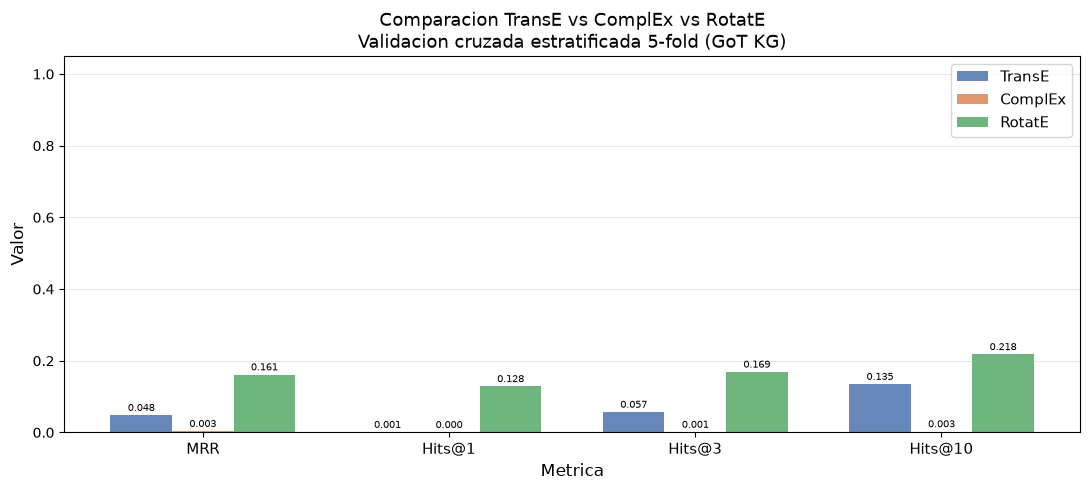

Grafico guardado en comparacion_modelos_KGE.png


In [ ]:
metrics_keys = ["MRR", "Hits@1", "Hits@3", "Hits@10"]
rows = [[m] + [f"{results_all[m][k]:.4f}" for k in metrics_keys] for m in MODELS]

print("COMPARACION FINAL --- Promedio 5-fold estratificado")
print("=" * 65)
print(tabulate(rows, headers=["Modelo"] + metrics_keys, tablefmt="github"))

best_model = max(results_all, key=lambda m: results_all[m]["MRR"])
best_mrr   = results_all[best_model]["MRR"]
print(f"Mejor modelo (MRR): {best_model}  ({best_mrr:.4f})")

print("\nVarianza entre folds (desviacion estandar):")
var_rows = []
for m in MODELS:
    stds = [float(np.std([detailed_folds[m][fi][k] for fi in range(k_folds)])) for k in metrics_keys]
    var_rows.append([m] + [f"{s:.4f}" for s in stds])
print(tabulate(var_rows, headers=["Modelo"] + metrics_keys, tablefmt="github"))

x      = np.arange(len(metrics_keys))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]
fig, ax = plt.subplots(figsize=(11, 5))

for idx, (model_name, color) in enumerate(zip(MODELS, colors)):
    values = [results_all[model_name][k] for k in metrics_keys]
    bars   = ax.bar(x + idx * width, values, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xlabel("Metrica", fontsize=12)
ax.set_ylabel("Valor", fontsize=12)
ax.set_title("Comparacion TransE vs ComplEx vs RotatE\nValidacion cruzada estratificada 5-fold (GoT KG)", fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_keys, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_modelos_KGE.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en comparacion_modelos_KGE.png")

#sustentar cantidad de datos utilizados para cada escenario. Justificar la eleccion según la desviación estándar y las demás métricas.
#Incluir el F1 Score.
